In [10]:
from pathlib import Path
import os

print("CWD =", Path.cwd())
PROJECT_ROOT = Path.cwd() / "govresponseai"
print("Try PROJECT_ROOT =", PROJECT_ROOT, "exists?", PROJECT_ROOT.exists())

if PROJECT_ROOT.exists():
    BASE = PROJECT_ROOT
else:
    BASE = Path.cwd()

print("BASE =", BASE)

CWD = /Users/wukezhang416
Try PROJECT_ROOT = /Users/wukezhang416/govresponseai exists? True
BASE = /Users/wukezhang416/govresponseai


In [11]:
from pathlib import Path
import pandas as pd

BASE = Path("/Users/wukezhang416/govresponseai")
df = pd.read_csv(BASE / "metadata" / "doc_index.csv")

print(df.shape)
display(df)

(7, 8)


,doc_id,country,title,issuing_body,date,url,format,notes
0,us_doc1,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,core framework
1,us_doc2,US,Blueprint for an AI Bill of Rights,OSTP/White House,2022-10-04,https://marketingstorageragrs.blob.core.window...,pdf,principles doc
2,us_doc3,US,OMB M-24-10: AI Governance & Risk Mgmt,OMB,2024-03-28,https://www.whitehouse.gov/wp-content/uploads/...,pdf,agency AI use governance memo
3,us_doc4,US,OMB M-24-18: Responsible AI Acquisition,OMB,2024-09-24,https://www.whitehouse.gov/wp-content/uploads/...,pdf,AI procurement memo
4,us_doc5,US,NIST AI 600-1: GenAI Profile,NIST,2024-07-01,https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.6...,pdf,GenAI risk profile companion to AI RMF
5,us_doc6,US,NIST AI RMF Playbook,NIST,2023-03-30,https://airc.nist.gov/docs/AI_RMF_Playbook.pdf,pdf,implementation playbook
6,us_doc7,US,NIST SP 800-218 SSDF,NIST,2022-02-03,https://nvlpubs.nist.gov/nistpubs/specialpubli...,pdf,governance/assurance framework baseline


In [12]:
import sys
!{sys.executable} -m pip install pdfplumber

In [13]:
import re, json, time
from pathlib import Path

import requests
import certifi
import pdfplumber

RAW = BASE / "data_raw"
PROCESSED = BASE / "data_processed"
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

def safe_filename(s: str) -> str:
    s = re.sub(r"[^a-zA-Z0-9._-]+", "_", s).strip("_")
    return s[:120] if len(s) > 120 else s

def download_file(url: str, out_path: Path, timeout=60):
    if out_path.exists() and out_path.stat().st_size > 0:
        return "cached"
    r = requests.get(
        url,
        timeout=timeout,
        headers={"User-Agent": "Mozilla/5.0"},
        verify=certifi.where(),   # 关键：解决 SSL CERTIFICATE_VERIFY_FAILED
    )
    r.raise_for_status()
    out_path.write_bytes(r.content)
    return "downloaded"

def parse_pdf_to_text(pdf_path: Path) -> str:
    texts = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        for page in pdf.pages:
            t = page.extract_text() or ""
            t = t.replace("\x00", " ")
            if t.strip():
                texts.append(t)
    return "\n".join(texts)

def chunk_text(text: str, max_chars=900):
    paras = [p.strip() for p in text.split("\n") if p.strip()]
    chunks, cur = [], ""
    for p in paras:
        if len(cur) + len(p) + 1 <= max_chars:
            cur = (cur + "\n" + p).strip()
        else:
            if cur:
                chunks.append(cur)
            cur = p
    if cur:
        chunks.append(cur)
    return chunks

records = []

for _, row in df.iterrows():
    doc_id = str(row["doc_id"])
    url = str(row["url"])
    fmt = str(row["format"]).lower().strip()
    title = str(row.get("title",""))
    issuing = str(row.get("issuing_body",""))
    date = str(row.get("date",""))

    if fmt != "pdf":
        raise ValueError("Right now please keep format as pdf for the first run.")

    fname = safe_filename(f"{doc_id}_{title}") or doc_id
    raw_path = RAW / f"{fname}.pdf"

    status = download_file(url, raw_path)
    print(f"{doc_id}: {status} -> {raw_path.name} ({raw_path.stat().st_size/1024:.1f} KB)")

    text = parse_pdf_to_text(raw_path)
    chunks = chunk_text(text)

    for i, ch in enumerate(chunks):
        records.append({
            "doc_id": doc_id,
            "chunk_id": f"{doc_id}_{i:04d}",
            "country": row["country"],
            "title": title,
            "issuing_body": issuing,
            "date": date,
            "url": url,
            "text": ch
        })

    time.sleep(1)

out_path = PROCESSED / "us_chunks.jsonl"
with out_path.open("w", encoding="utf-8") as f:
    for rec in records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Total chunks:", len(records))
print("Saved to:", out_path)

us_doc1: cached -> us_doc1_AI_Risk_Management_Framework_1.0.pdf (1900.5 KB)
us_doc2: cached -> us_doc2_Blueprint_for_an_AI_Bill_of_Rights.pdf (11401.3 KB)
us_doc3: downloaded -> us_doc3_OMB_M-24-10_AI_Governance_Risk_Mgmt.pdf (518.1 KB)
us_doc4: downloaded -> us_doc4_OMB_M-24-18_Responsible_AI_Acquisition.pdf (447.9 KB)
us_doc5: downloaded -> us_doc5_NIST_AI_600-1_GenAI_Profile.pdf (1147.1 KB)
us_doc6: downloaded -> us_doc6_NIST_AI_RMF_Playbook.pdf (2814.7 KB)
us_doc7: downloaded -> us_doc7_NIST_SP_800-218_SSDF.pdf (722.5 KB)
Total chunks: 1323
Saved to: /Users/wukezhang416/govresponseai/data_processed/us_chunks.jsonl


In [14]:
import json
from pathlib import Path

path = Path("/Users/wukezhang416/govresponseai/data_processed/us_chunks.jsonl")

with path.open("r", encoding="utf-8") as f:
    for i in range(3):
        rec = json.loads(next(f))
        print("chunk_id:", rec["chunk_id"])
        print(rec["text"][:500])
        print("-----")

chunk_id: us_doc1_0000
NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
Thispublicationisavailablefreeofchargefrom:
https://doi.org/10.6028/NIST.AI.100-1
January2023
U.S.DepartmentofCommerce
GinaM.Raimondo,Secretary
NationalInstituteofStandardsandTechnology
LaurieE.Locascio,NISTDirectorandUnderSecretaryofCommerceforStandardsandTechnology
Certain commercial entities, equipment, or materials may be identified in this
-----
chunk_id: us_doc1_0001
Thispublicationisavailablefreeofchargefrom: https://doi.org/10.6028/NIST.AI.100-1
UpdateScheduleandVersions
TheArtificialIntelligenceRiskManagementFramework(AIRMF)isintendedtobealivingdocument.
NISTwillreviewthecontentandusefulnessoftheFrameworkregularlytodetermineifanupdateisappro-
priate;areviewwithformalinputfromtheAIcommunityisexpectedtotakeplacenolaterthan2028. The
Frameworkwillemployatwo-numberversioningsystemtotrackandidentifymajorandmi

In [15]:
import json, re
from pathlib import Path
import pandas as pd

path = Path("/Users/wukezhang416/govresponseai/data_processed/us_chunks.jsonl")

# 5 categories + starter keyword lists (you can refine later)
KEYWORDS = {
    "TRANSPARENCY": [
        "transparen", "explain", "interpretab", "disclos", "notice", "documentation"
    ],
    "OVERSIGHT_AUDIT": [
        "audit", "oversight", "governance", "monitor", "evaluation", "assess", "review"
    ],
    "ACCOUNTABILITY_LIABILITY": [
        "accountab", "responsib", "liabil", "enforcement", "penalt", "compliance"
    ],
    "PUBLIC_PARTICIPATION": [
        "public", "stakeholder", "consult", "engage", "participat", "comment"
    ],
    "APPEALS_REMEDY": [
        "appeal", "complaint", "redress", "remedy", "grievance", "recourse"
    ],
}

def tag_chunk(text: str):
    t = text.lower()
    tags = {}
    for cat, kws in KEYWORDS.items():
        tags[cat] = int(any(kw in t for kw in kws))
    return tags

rows = []
with path.open("r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        tags = tag_chunk(rec["text"])
        rows.append({
            "doc_id": rec["doc_id"],
            "chunk_id": rec["chunk_id"],
            **tags
        })

df_tags = pd.DataFrame(rows)
df_tags.head()

,doc_id,chunk_id,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY
0,us_doc1,us_doc1_0000,0,0,0,1,0
1,us_doc1,us_doc1_0001,0,1,0,1,0
2,us_doc1,us_doc1_0002,1,1,1,1,0
3,us_doc1,us_doc1_0003,0,0,1,0,0
4,us_doc1,us_doc1_0004,1,1,1,0,0


In [16]:
summary = df_tags.groupby("doc_id")[list(KEYWORDS.keys())].mean().reset_index()
summary

,doc_id,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY
0,us_doc1,0.237288,0.432203,0.355932,0.186441,0.033898
1,us_doc2,0.223938,0.498069,0.208494,0.428571,0.042471
2,us_doc3,0.184874,0.588235,0.462185,0.411765,0.025210
3,us_doc4,0.261538,0.453846,0.300000,0.284615,0.030769
4,us_doc5,0.308108,0.524324,0.200000,0.351351,0.021622
5,us_doc6,0.572165,0.595361,0.456186,0.337629,0.023196
6,us_doc7,0.064516,0.387097,0.161290,0.306452,0.000000


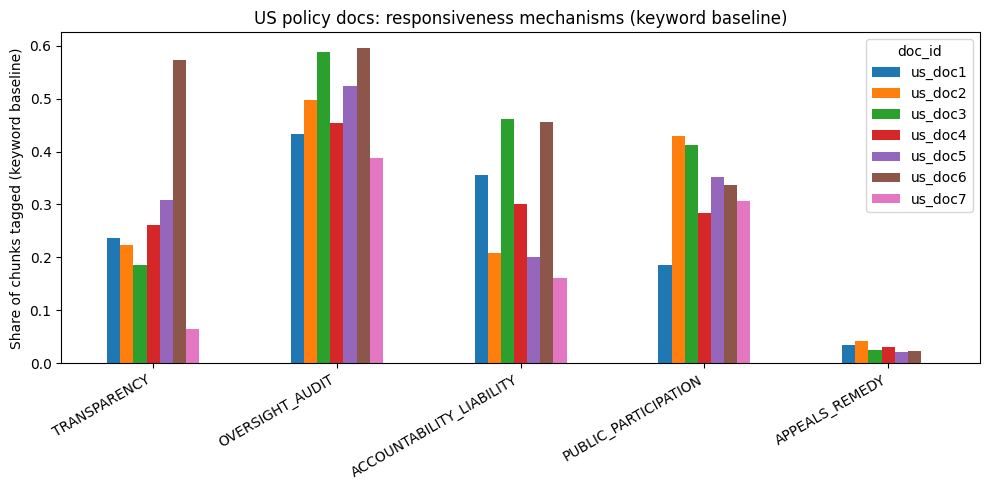

In [17]:
import matplotlib.pyplot as plt

cats = ["TRANSPARENCY","OVERSIGHT_AUDIT","ACCOUNTABILITY_LIABILITY","PUBLIC_PARTICIPATION","APPEALS_REMEDY"]

plot_df = summary.set_index("doc_id")[cats]
ax = plot_df.T.plot(kind="bar", figsize=(10,5))
ax.set_ylabel("Share of chunks tagged (keyword baseline)")
ax.set_title("US policy docs: responsiveness mechanisms (keyword baseline)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import json
from pathlib import Path

path = Path("/Users/wukezhang416/govresponseai/data_processed/us_chunks.jsonl")

# load chunks with text
rows = []
with path.open("r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))
df_text = pd.DataFrame(rows)

df_merge = df_tags.merge(df_text[["chunk_id","text","doc_id"]], on=["chunk_id","doc_id"], how="left")

examples = []
for cat in cats:
    subset = df_merge[df_merge[cat] == 1].head(2)  # first 2 examples
    for _, r in subset.iterrows():
        examples.append({"category": cat, "doc_id": r["doc_id"], "chunk_id": r["chunk_id"], "text_snippet": r["text"][:220].replace("\n"," ")+"..."})

examples_df = pd.DataFrame(examples)
examples_df

,category,doc_id,chunk_id,text_snippet
0,TRANSPARENCY,us_doc1,us_doc1_0002,frequently.CommentsontheAIRMFPlaybookmaybesent...
1,TRANSPARENCY,us_doc1,us_doc1_0004,mensions and the outer circle shows AI lifecyc...
2,OVERSIGHT_AUDIT,us_doc1,us_doc1_0001,Thispublicationisavailablefreeofchargefrom: ht...
3,OVERSIGHT_AUDIT,us_doc1,us_doc1_0002,frequently.CommentsontheAIRMFPlaybookmaybesent...
4,ACCOUNTABILITY_LIABILITY,us_doc1,us_doc1_0002,frequently.CommentsontheAIRMFPlaybookmaybesent...
5,ACCOUNTABILITY_LIABILITY,us_doc1,us_doc1_0003,AppendixB:HowAIRisksDifferfromTraditionalSoftw...
6,PUBLIC_PARTICIPATION,us_doc1,us_doc1_0000,NIST AI 100-1 Artificial Intelligence Risk Man...
7,PUBLIC_PARTICIPATION,us_doc1,us_doc1_0001,Thispublicationisavailablefreeofchargefrom: ht...
8,APPEALS_REMEDY,us_doc1,us_doc1_0047,necessaryforactionableredressrelatedtoAIsystem...
9,APPEALS_REMEDY,us_doc1,us_doc1_0085,trackingidentified and emergent AI risks based...
